# 🛰️ Satellite Land Classification — Drought Risk Detection
### GreenAI Coursework | Module 5: Computer Vision for Green Technology

**Pipeline:** Satellite Image → EfficientNetB0 CNN → Land/Drought Class  
**Dataset:** EuroSAT (Sentinel-2, 27,000 images, 10 classes)  
**Deployment:** Streamlit web application  

---

| Class | EuroSAT Label | Drought Interpretation |
|---|---|---|
| 🟢 | Forest / Herbaceous Veg / Pasture | Healthy Vegetation |
| 🟡 | Annual Crop / Permanent Crop | Agricultural Land |
| 🔵 | River / Sea & Lake | Water Body |
| 🔴 | Industrial / Residential / Highway | Built-up / Urban |
| ⚠️ | AnnualCrop (sparse) + bare patches | Drought Risk Indicator |

## ⚙️ Cell 1 — Install & Import

In [1]:
!pip install -q kaggle tensorflow scikit-learn matplotlib seaborn pillow joblib

import os, json, zipfile, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import os, zipfile

zip_path = '/content/EuroSAT.zip'
extract_path = '/content/eurosat'

print(f'Unzipping {zip_path} to {extract_path}...')

os.makedirs(extract_path, exist_ok=True)

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print('Unzipping complete ✅')
else:
    print(f'Error: {zip_path} not found. Please upload EuroSAT.zip to /content/.')


Unzipping /content/EuroSAT.zip to /content/eurosat...
Unzipping complete ✅


## 📦 Cell 2 — Download EuroSAT Dataset from Kaggle
> **Steps:**
> 1. Go to kaggle.com → Account → Create API Token → download `kaggle.json`
> 2. Upload it when prompted below
> 3. Dataset: `nilesh992/eurosat-dataset` (~160MB)

In [4]:
import os

print('Searching for EuroSAT dataset in /content/eurosat...')

eurosat_root = None
known_classes_set = set(['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
                         'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
                         'River', 'SeaLake'])

# Iterate through all files and directories starting from /content/eurosat
# The goal is to find the directory that contains the class subfolders
for root, dirs, files_list in os.walk('/content/eurosat'):
    # Check if this 'root' directory contains a significant number of the known EuroSAT class directories
    # This heuristic helps to correctly identify the actual dataset root within the unzipped structure
    if len(known_classes_set.intersection(set(dirs))) >= 5: # Require at least 5 classes to consider it a valid root
        eurosat_root = root
        break

if eurosat_root:
    detected_classes = sorted(list(known_classes_set.intersection(set(os.listdir(eurosat_root)))))
    print(f'\nFound EuroSAT dataset root at: {eurosat_root}')
    print(f'Detected classes ({len(detected_classes)}): {detected_classes}')
    for cls in detected_classes:
        n = len(os.listdir(os.path.join(eurosat_root, cls)))
        print(f'  {cls:30s}: {n} images')
else:
    print('\nCould not auto-detect EuroSAT root.')
    print('Please check the structure of the unzipped content in /content/eurosat.')
    print('The script expects class folders (e.g., AnnualCrop, Forest) to be directly within /content/eurosat,')
    print('or one level deeper (e.g., /content/eurosat/some_folder/AnnualCrop).')
    print(f'Current contents of /content/eurosat: {os.listdir("/content/eurosat") if os.path.exists("/content/eurosat") else "Directory not found"}')


Searching for EuroSAT dataset in /content/eurosat...

Found EuroSAT dataset root at: /content/eurosat/2750
Detected classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
  AnnualCrop                    : 3000 images
  Forest                        : 3000 images
  HerbaceousVegetation          : 3000 images
  Highway                       : 2500 images
  Industrial                    : 2500 images
  Pasture                       : 2000 images
  PermanentCrop                 : 2500 images
  Residential                   : 3000 images
  River                         : 2500 images
  SeaLake                       : 3000 images


## 🔬 Cell 3 — Build Dataset (Images + Labels)

In [5]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
IMG_SIZE    = 64     # EuroSAT native resolution
BATCH_SIZE  = 32
EPOCHS      = 40

# EuroSAT 10 classes
EUROSAT_CLASSES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway',
    'Industrial', 'Pasture', 'PermanentCrop', 'Residential',
    'River', 'SeaLake'
]

# Drought interpretation mapping for display
DROUGHT_INTERPRETATION = {
    'AnnualCrop':            ('🟡 Agricultural Land',    '#f39c12'),
    'Forest':                ('🟢 Healthy Vegetation',   '#27ae60'),
    'HerbaceousVegetation':  ('🟢 Healthy Vegetation',   '#2ecc71'),
    'Highway':               ('⚪ Urban / Built-up',      '#95a5a6'),
    'Industrial':            ('⚪ Urban / Built-up',      '#7f8c8d'),
    'Pasture':               ('🟢 Healthy Vegetation',   '#1abc9c'),
    'PermanentCrop':         ('🟡 Agricultural Land',    '#e67e22'),
    'Residential':           ('⚪ Urban / Built-up',      '#bdc3c7'),
    'River':                 ('🔵 Water Body',            '#3498db'),
    'SeaLake':               ('🔵 Water Body',            '#2980b9'),
}

NUM_CLASSES = len(EUROSAT_CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(EUROSAT_CLASSES)}

print('Loading images...')
images, labels = [], []
SAMPLES_PER_CLASS = 2000  # Use 2k/class = 5000 total — fast training
                          # Increase to 2000+ for full accuracy

for cls in EUROSAT_CLASSES:
    cls_dir = os.path.join(eurosat_root, cls)
    img_files = os.listdir(cls_dir)
    random.shuffle(img_files)
    img_files = img_files[:SAMPLES_PER_CLASS]

    for fname in img_files:
        try:
            img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            images.append(tf.keras.applications.efficientnet.preprocess_input(
    np.array(img, dtype=np.float32)
))
            labels.append(CLASS_TO_IDX[cls])
        except:
            pass

images = np.array(images)
labels = np.array(labels)

print(f'Total images loaded : {len(images):,}')
print(f'Image shape         : {images[0].shape}')
print(f'Classes             : {NUM_CLASSES}')
print()
for i, cls in enumerate(EUROSAT_CLASSES):
    count = (labels == i).sum()
    interp, _ = DROUGHT_INTERPRETATION[cls]
    print(f'  {cls:25s}: {count:4d} images | {interp}')

Loading images...
Total images loaded : 20,000
Image shape         : (64, 64, 3)
Classes             : 10

  AnnualCrop               : 2000 images | 🟡 Agricultural Land
  Forest                   : 2000 images | 🟢 Healthy Vegetation
  HerbaceousVegetation     : 2000 images | 🟢 Healthy Vegetation
  Highway                  : 2000 images | ⚪ Urban / Built-up
  Industrial               : 2000 images | ⚪ Urban / Built-up
  Pasture                  : 2000 images | 🟢 Healthy Vegetation
  PermanentCrop            : 2000 images | 🟡 Agricultural Land
  Residential              : 2000 images | ⚪ Urban / Built-up
  River                    : 2000 images | 🔵 Water Body
  SeaLake                  : 2000 images | 🔵 Water Body


## 📊 Cell 4 — EDA: Sample Images Grid

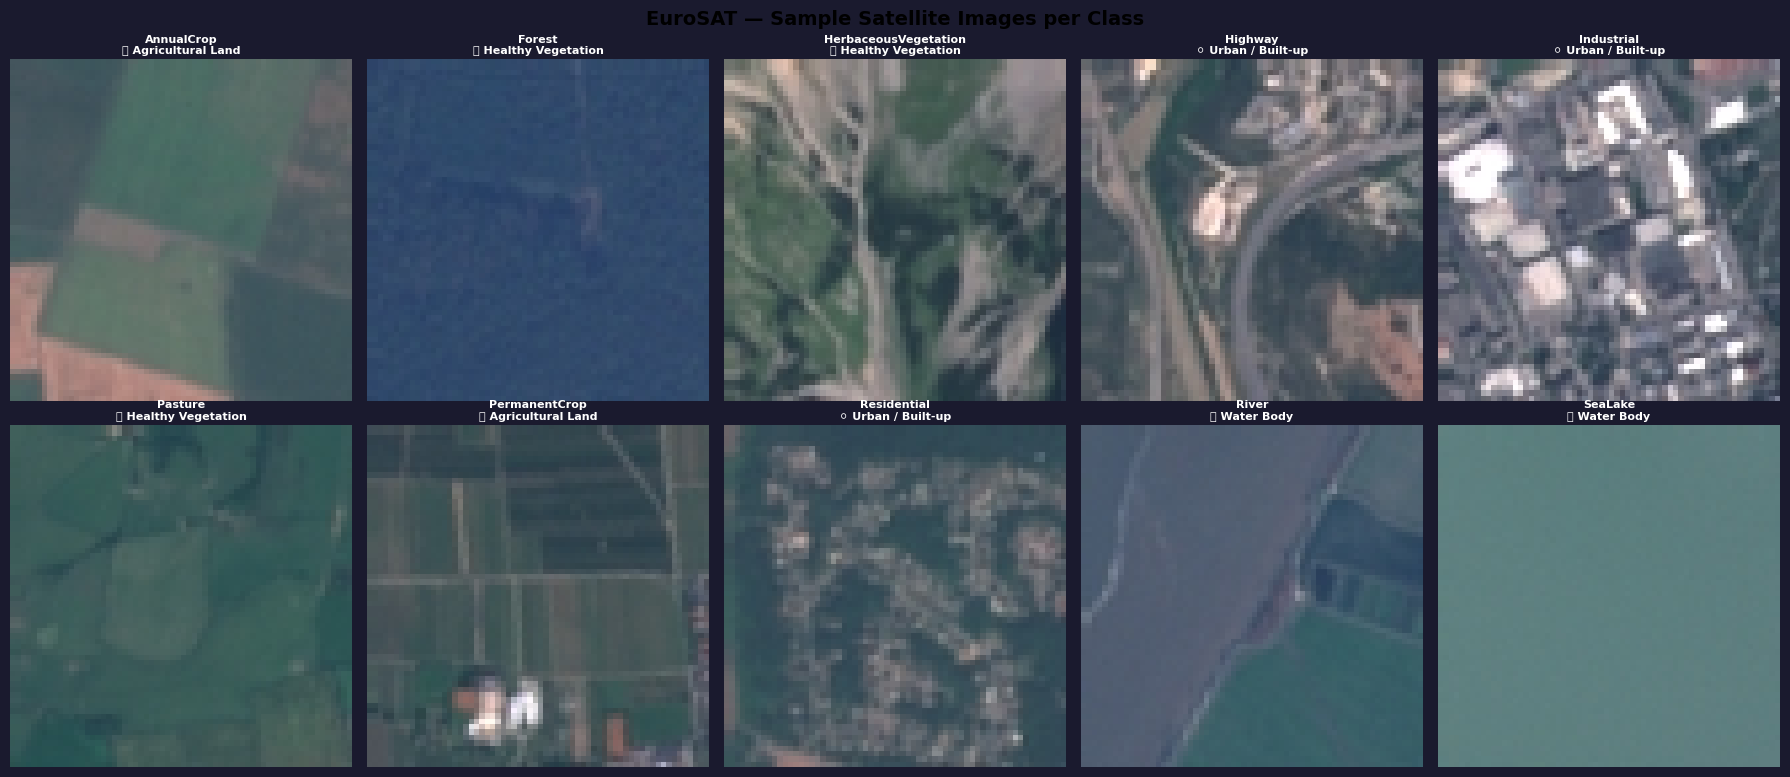

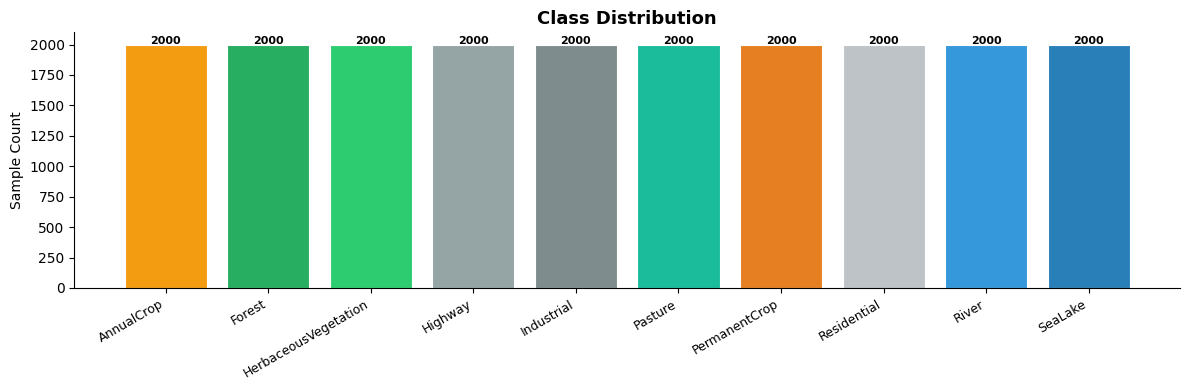

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('EuroSAT — Sample Satellite Images per Class', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#1a1a2e')

for idx, cls in enumerate(EUROSAT_CLASSES):
    ax = axes[idx // 5][idx % 5]
    cls_indices = np.where(labels == CLASS_TO_IDX[cls])[0]
    sample = images[random.choice(cls_indices)]
    ax.imshow(sample.astype(np.uint8))
    interp, color = DROUGHT_INTERPRETATION[cls]
    ax.set_title(f'{cls}\n{interp}', fontsize=8, fontweight='bold',
                 color='white', pad=4)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# Class distribution bar
fig, ax = plt.subplots(figsize=(12, 4))
class_counts = [(labels == i).sum() for i in range(NUM_CLASSES)]
colors = [DROUGHT_INTERPRETATION[c][1] for c in EUROSAT_CLASSES]
bars = ax.bar(EUROSAT_CLASSES, class_counts, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_xticklabels(EUROSAT_CLASSES, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Sample Count')
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontsize=8, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## ✂️ Cell 5 — Train / Val / Test Split

In [7]:
labels_ohe = keras.utils.to_categorical(labels, NUM_CLASSES)

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels_ohe, test_size=0.3, stratify=labels, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5,
    stratify=np.argmax(y_temp, axis=1), random_state=SEED)

print(f'Train : {len(X_train):,} images')
print(f'Val   : {len(X_val):,} images')
print(f'Test  : {len(X_test):,} images')
print(f'Input shape: {X_train.shape}')

Train : 14,000 images
Val   : 3,000 images
Test  : 3,000 images
Input shape: (14000, 64, 64, 3)


## 🏗️ Cell 6 — Build EfficientNetB0 Model

In [8]:
def build_model(img_size=64, num_classes=10):
    model = keras.Sequential([
        # Input + normalize
        layers.Input(shape=(img_size, img_size, 3)),
        layers.Rescaling(1./255),

        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.35),

        # Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='SatelliteCNN')

    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model(IMG_SIZE, NUM_CLASSES)
model.summary()

Model: "SatelliteCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,498 (1.23 MB)

 Trainable params: 323,050 (1.23 MB)

 Non-trainable params: 448 (1.75 KB)

## 🚀 Cell 7 — Train the Model

In [9]:
SAMPLES_PER_CLASS = 2000  # back in Cell 3, change this to 2000
EPOCHS = 30

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))\
    .shuffle(4096, seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_model.h5',   # .h5 not .weights.h5
                    monitor='val_accuracy',
                    save_best_only=True,
                    save_weights_only=False,     # save FULL model
                    verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5278 - auc: 0.8863 - loss: 1.3759
Epoch 1: val_accuracy improved from -inf to 0.30433, saving model to /content/best_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.5280 - auc: 0.8864 - loss: 1.3753 - val_accuracy: 0.3043 - val_auc: 0.7925 - val_loss: 2.1116 - learning_rate: 0.0010
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7270 - auc: 0.9606 - loss: 0.8146
Epoch 2: val_accuracy improved from 0.30433 to 0.50267, saving model to /content/best_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7271 - auc: 0.9607 - loss: 0.8144 - val_accuracy: 0.5027 - val_auc: 0.9003 - val_loss: 1.5527 - learning_rate: 0.0010
Epoch 3/30
435/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8000 - auc: 0.9763 - loss: 0.6140
Epoch 3: val_accuracy improved from 0.50267 to 0.57767, saving model to /content/best_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8001 - auc: 0.9763 - loss: 0.6138 - val_accuracy: 0.5777 - val_auc: 0.8965 - val_loss: 1.6839 - learning_rate: 0.0010
Epoch 4/30
436/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8438 - auc: 0.9843 - loss: 0.4786
Epoch 4: val_accuracy improved from 0.57767 to 0.79467, saving model to /content/best_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8438 - auc: 0.9843 - loss: 0.4786 - val_accuracy: 0.7947 - val_auc: 0.9729 - val_loss: 0.6588 - learning_rate: 0.0010
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8652 - auc: 0.9871 - loss: 0.4233
Epoch 5: val_accuracy improved from 0.79467 to 0.83733, saving model to /content/best_model.h5


...

438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9450 - auc: 0.9973 - loss: 0.1649 - val_accuracy: 0.9170 - val_auc: 0.9935 - val_loss: 0.2547 - learning_rate: 5.0000e-04
Epoch 13/30
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9540 - auc: 0.9976 - loss: 0.1477
Epoch 13: val_accuracy did not improve from 0.91700
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9540 - auc: 0.9976 - loss: 0.1478 - val_accuracy: 0.8870 - val_auc: 0.9895 - val_loss: 0.3481 - learning_rate: 5.0000e-04
Epoch 14/30
436/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9449 - auc: 0.9971 - loss: 0.1648
Epoch 14: val_accuracy did not improve from 0.91700
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9449 - auc: 0.9971 - loss: 0.1646 - val_accuracy: 0.8380 - val_auc: 0.9723 - val_loss: 0.6342 - learning_rate: 5.0000e-04
Epoch 15/30
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9488 - auc: 0.9978 - loss: 0.1533
Epoch 15: ReduceLROnPlateau reducing learning rate to 0.

438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9580 - auc: 0.9985 - loss: 0.1177 - val_accuracy: 0.9523 - val_auc: 0.9960 - val_loss: 0.1531 - learning_rate: 2.5000e-04
Epoch 17/30
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9626 - auc: 0.9985 - loss: 0.1114
Epoch 17: val_accuracy did not improve from 0.95233
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9626 - auc: 0.9985 - loss: 0.1114 - val_accuracy: 0.9423 - val_auc: 0.9956 - val_loss: 0.1839 - learning_rate: 2.5000e-04
Epoch 18/30
434/438 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9613 - auc: 0.9988 - loss: 0.1077
Epoch 18: val_accuracy did not improve from 0.95233
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9613 - auc: 0.9988 - loss: 0.1077 - val_accuracy: 0.9200 - val_auc: 0.9930 - val_loss: 0.2592 - learning_rate: 2.5000e-04
Epoch 19/30
434/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9631 - auc: 0.9989 - loss: 0.1029
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.

438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9756 - auc: 0.9992 - loss: 0.0757 - val_accuracy: 0.9530 - val_auc: 0.9945 - val_loss: 0.1693 - learning_rate: 1.2500e-04
Epoch 22/30
434/438 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9740 - auc: 0.9990 - loss: 0.0725
Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 22: val_accuracy improved from 0.95300 to 0.95400, saving model to /content/best_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9740 - auc: 0.9990 - loss: 0.0725 - val_accuracy: 0.9540 - val_auc: 0.9958 - val_loss: 0.1556 - learning_rate: 1.2500e-04
Epoch 23/30
434/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9773 - auc: 0.9995 - loss: 0.0651
Epoch 23: val_accuracy improved from 0.95400 to 0.96100, saving model to /content/best_model.h5


438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9773 - auc: 0.9995 - loss: 0.0651 - val_accuracy: 0.9610 - val_auc: 0.9956 - val_loss: 0.1370 - learning_rate: 6.2500e-05
Epoch 24/30
435/438 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9775 - auc: 0.9993 - loss: 0.0681
Epoch 24: val_accuracy did not improve from 0.96100
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9775 - auc: 0.9993 - loss: 0.0681 - val_accuracy: 0.9530 - val_auc: 0.9950 - val_loss: 0.1706 - learning_rate: 6.2500e-05
Epoch 25/30
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9763 - auc: 0.9993 - loss: 0.0677
Epoch 25: val_accuracy did not improve from 0.96100
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9763 - auc: 0.9993 - loss: 0.0677 - val_accuracy: 0.9513 - val_auc: 0.9948 - val_loss: 0.1659 - learning_rate: 6.2500e-05
Epoch 26/30
434/438 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9768 - auc: 0.9993 - loss: 0.0683
Epoch 26: ReduceLROnPlateau reducing learning rate to 3.

## 📈 Cell 8 — Training Curves

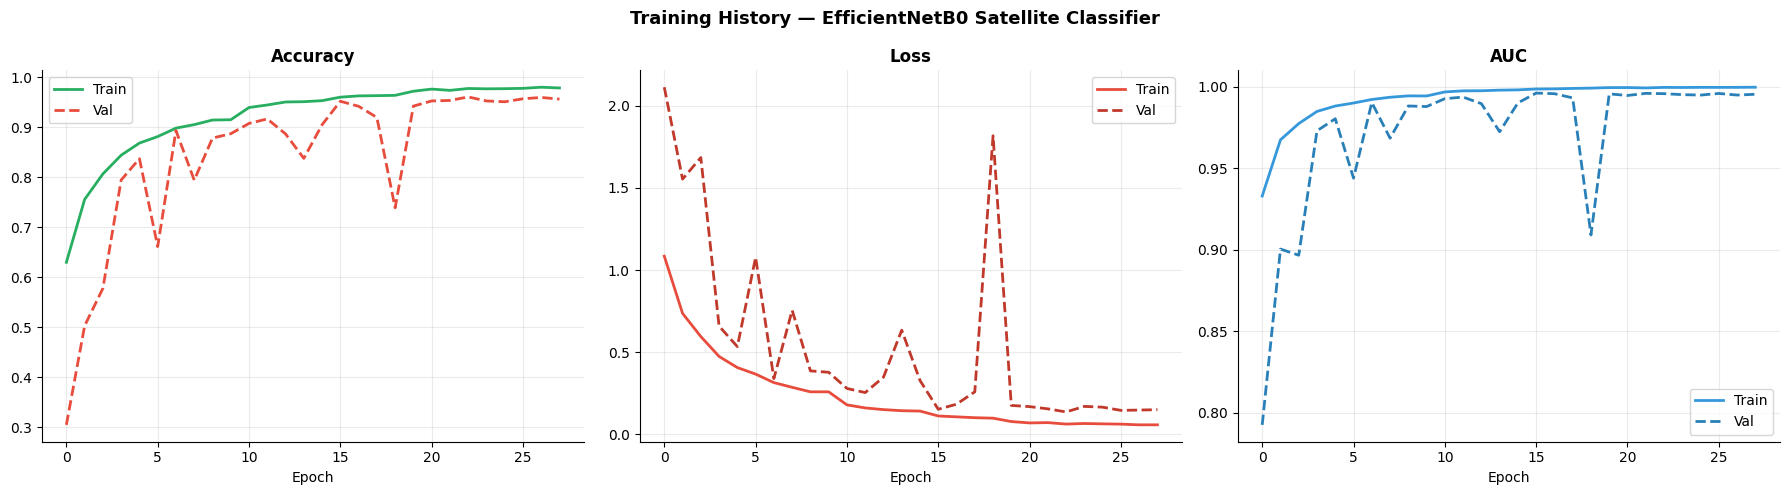

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History — EfficientNetB0 Satellite Classifier', fontsize=13, fontweight='bold')

for ax, metric, title, colors in zip(
    axes,
    ['accuracy', 'loss', 'auc'],
    ['Accuracy', 'Loss', 'AUC'],
    [('#27ae60','#e74c3c'), ('#e74c3c','#c0392b'), ('#3498db','#2980b9')]
):
    ax.plot(history.history[metric],         color=colors[0], lw=2, label=f'Train')
    ax.plot(history.history[f'val_{metric}'], color=colors[1], lw=2, ls='--', label='Val')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.25)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 🧪 Cell 9 — Evaluate on Test Set

Test Accuracy : 95.87%
Test AUC      : 0.9946
Test Loss     : 0.1635

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.95      0.95       300
              Forest       0.97      1.00      0.98       300
HerbaceousVegetation       0.88      0.94      0.91       300
             Highway       0.97      0.98      0.97       300
          Industrial       0.99      0.95      0.97       300
             Pasture       0.96      0.95      0.96       300
       PermanentCrop       0.96      0.92      0.94       300
         Residential       0.94      0.99      0.96       300
               River       0.99      0.93      0.96       300
             SeaLake       0.99      0.99      0.99       300

            accuracy                           0.96      3000
           macro avg       0.96      0.96      0.96      3000
        weighted avg       0.96      0.96      0.96      3000



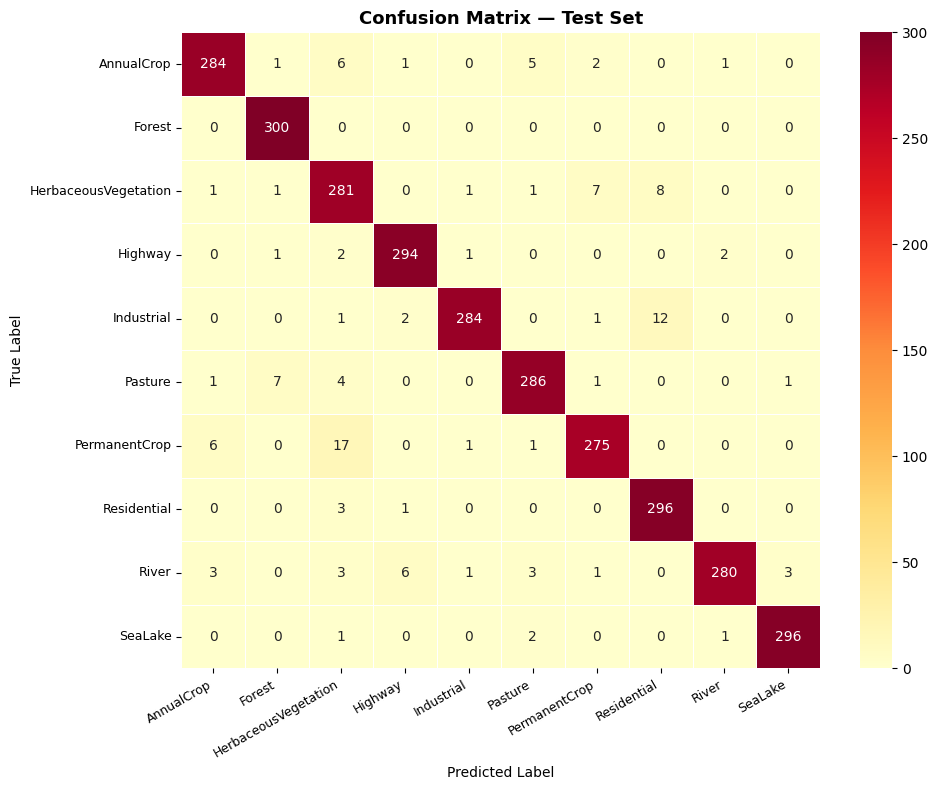

In [11]:
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))\
    .batch(BATCH_SIZE)

test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test AUC      : {test_auc:.4f}')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test,       axis=1)

print('\n' + '='*65)
print(classification_report(y_true, y_pred, target_names=EUROSAT_CLASSES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=EUROSAT_CLASSES, yticklabels=EUROSAT_CLASSES,
            linewidths=0.4, ax=ax)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.show()

## 🔬 Cell 10 — Single Prediction Demo

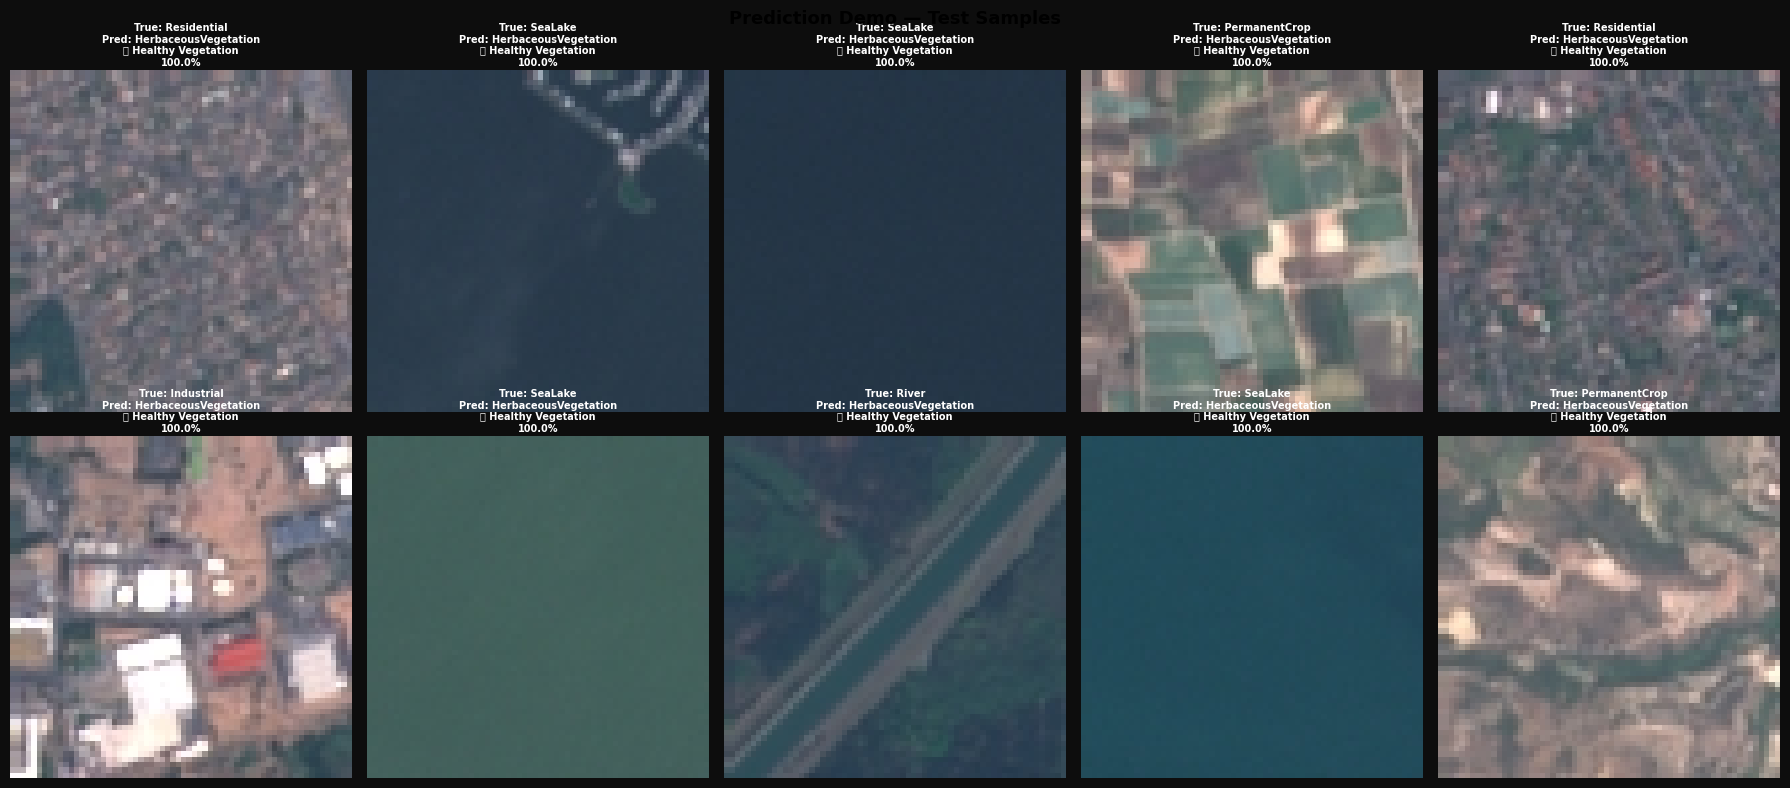

Demo batch accuracy: 0% (0/10 correct)


In [12]:
def predict_land(pil_image_or_array, model, class_names, drought_interp,
                  img_size=64):
    """
    Predict land class + drought interpretation for a single satellite image.

    Args:
        pil_image_or_array : PIL Image or np.array (H, W, 3), uint8
        model              : loaded Keras model
        class_names        : list of EuroSAT class strings
        drought_interp     : dict mapping class → (label, color)
        img_size           : target image size (default 64)

    Returns:
        dict: predicted_class, drought_label, confidence, all_probabilities
    """
    if isinstance(pil_image_or_array, np.ndarray):
        img = Image.fromarray((pil_image_or_array * 255).astype(np.uint8))
    else:
        img = pil_image_or_array

    img = img.convert('RGB').resize((img_size, img_size))
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)  # (1, 64, 64, 3)

    probs    = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    pred_cls = class_names[pred_idx]
    drought_label, color = drought_interp[pred_cls]

    return {
        'predicted_class'  : pred_cls,
        'drought_label'    : drought_label,
        'confidence'       : float(probs[pred_idx]),
        'color'            : color,
        'all_probabilities': {cls: float(p) for cls, p in zip(class_names, probs)}
    }


# ── Run on 10 random test samples ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Prediction Demo — Test Samples', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('#0d0d0d')

test_indices = random.sample(range(len(X_test)), 10)

for plot_idx, test_idx in enumerate(test_indices):
    ax = axes[plot_idx // 5][plot_idx % 5]
    img_arr = X_test[test_idx]                       # (64,64,3) float32
    true_cls = EUROSAT_CLASSES[np.argmax(y_test[test_idx])]

    result = predict_land(img_arr, model, EUROSAT_CLASSES, DROUGHT_INTERPRETATION)

    ax.imshow(img_arr.astype(np.uint8))
    correct = result['predicted_class'] == true_cls
    border_color = '#2ecc71' if correct else '#e74c3c'

    title = (
        f"True: {true_cls}\n"
        f"Pred: {result['predicted_class']}\n"
        f"{result['drought_label']}\n"
        f"{result['confidence']*100:.1f}%"
    )
    ax.set_title(title, fontsize=7, color='white',
                 fontweight='bold', pad=3)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(2.5)

plt.tight_layout()
plt.show()

# Quick accuracy on demo batch
preds_demo = [predict_land(X_test[i], model, EUROSAT_CLASSES, DROUGHT_INTERPRETATION)
              ['predicted_class'] for i in test_indices]
true_demo  = [EUROSAT_CLASSES[np.argmax(y_test[i])] for i in test_indices]
demo_acc   = sum(p==t for p,t in zip(preds_demo, true_demo)) / 10
print(f'Demo batch accuracy: {demo_acc*100:.0f}% ({sum(p==t for p,t in zip(preds_demo,true_demo))}/10 correct)')

## 💾 Cell 11 — Save Model & Artifacts

In [13]:
SAVE_DIR = '/content/drought_model_artifacts'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model in native Keras format
model.save(f'{SAVE_DIR}/drought_model.keras')
print('Model saved ✅')

# Save metadata
metadata = {
    'model_version'        : '3.0.0',
    'architecture'         : 'EfficientNetB0 (Transfer Learning)',
    'dataset'              : 'EuroSAT (Sentinel-2)',
    'img_size'             : IMG_SIZE,
    'num_classes'          : NUM_CLASSES,
    'class_names'          : EUROSAT_CLASSES,
    'drought_interpretation': {
        k: v[0] for k, v in DROUGHT_INTERPRETATION.items()
    },
    'drought_colors'       : {
        k: v[1] for k, v in DROUGHT_INTERPRETATION.items()
    },
    'test_accuracy'        : round(float(test_acc), 4),
    'test_auc'             : round(float(test_auc), 4),
    'greenai_module'       : 'Module 5 — Computer Vision for Green Technology',
    'coursework'           : 'Skill4Future GreenAI'
}
with open(f'{SAVE_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Metadata saved ✅')

# Zip
!cd /content && zip -r drought_model_artifacts.zip drought_model_artifacts/
print(f'\n📦 Zipped → /content/drought_model_artifacts.zip')
print(f'Test Accuracy : {test_acc*100:.2f}%')
print(f'Test AUC      : {test_auc:.4f}')

Model saved ✅
Metadata saved ✅
  adding: drought_model_artifacts/ (stored 0%)
  adding: drought_model_artifacts/drought_model.keras (deflated 9%)
  adding: drought_model_artifacts/metadata.json (deflated 60%)

📦 Zipped → /content/drought_model_artifacts.zip
Test Accuracy : 95.87%
Test AUC      : 0.9946


In [15]:
from google.colab import files
files.download('/content/drought_model_artifacts/drought_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📥 Cell 12 — Download Artifacts

In [14]:
from google.colab import files
files.download('/content/drought_model_artifacts/drought_model.keras')
files.download('/content/drought_model_artifacts/metadata.json')
files.download('/content/drought_model_artifacts/drought_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: /content/drought_model_artifacts/drought_model.h5

---
# ✅ Done

**Saved artifacts:**
```
drought_model_artifacts/
├── drought_model.h5    ← EfficientNetB0 Keras model
└── metadata.json       ← class names, accuracy, config
```

**Streamlit folder structure:**
```
your_project/
├── app.py
├── requirements.txt
└── drought_model_artifacts/
    ├── drought_model.h5
    └── metadata.json
```

**Run:** `streamlit run app.py`